# Comparing Scanpaths with MultiMatch

A single similarity number can hide important differences between scanpaths.
Two people might fixate the same locations but in a completely different order,
or follow the same trajectory but at different speeds. MultiMatch
(Dewhurst et al., 2012) addresses this by evaluating scanpath similarity
across five distinct dimensions:

| Dimension | What it captures |
|:----------|:-----------------|
| **vector** | Overall shape similarity of saccade vectors |
| **direction** | Angular similarity of saccade directions |
| **length** | Similarity of saccade amplitudes |
| **position** | Spatial proximity of corresponding fixations |
| **duration** | Similarity of fixation durations |

The `peyesim` implementation adds a sixth metric, **position_emd**, based on
the earth mover's distance between fixation locations. This captures
distributional similarity that is not order-dependent.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from peyesim import fixation_group, scanpath, multi_match

## How do you compare two scanpaths?

Start by creating two `fixation_group` objects, convert them to `Scanpath`
objects, and call `multi_match()`:

In [2]:
rng = np.random.default_rng(1)

def simulate_linear(n, rng):
    return fixation_group(
        x=np.cumsum(rng.normal(50, 10, n)),
        y=np.cumsum(rng.normal(50, 10, n)),
        duration=rng.poisson(200, n),
        onset=np.arange(1, n + 1, dtype=float),
    )

fg1 = simulate_linear(10, rng)
fg2 = simulate_linear(12, rng)

In [3]:
sp1 = scanpath(fg1)
sp2 = scanpath(fg2)
multi_match(sp1, sp2, screensize=(500, 500))

{'mm_vector': 0.9953692819729023,
 'mm_direction': 0.9810273190055653,
 'mm_length': 0.995366243784605,
 'mm_position': 0.8259900273967983,
 'mm_duration': 0.9577677224736049,
 'mm_position_emd': 0.9718939908679336}

All metrics are high, consistent with the known similarity of the two
scanpaths.

## What happens when scanpaths differ structurally?

Let's compare a linear scanpath against a zigzag pattern:

In [4]:
fg_zigzag = fixation_group(
    x=np.cumsum(np.full(10, 50.0)),
    y=np.cumsum(np.array([50, -50, 50, -50, 50, -50, 50, -50, 50, -50], dtype=float)),
    duration=rng.poisson(200, 10),
    onset=np.arange(1, 11, dtype=float),
)

sp_linear = scanpath(simulate_linear(10, rng))
sp_zigzag = scanpath(fg_zigzag)
multi_match(sp_linear, sp_zigzag, screensize=(500, 500))

{'mm_vector': 0.934822833219594,
 'mm_direction': 0.5689971201981094,
 'mm_length': 0.9848072031737578,
 'mm_position': 0.7252696659935799,
 'mm_duration': 0.9077669902912622,
 'mm_position_emd': 0.6984210040608405}

Notice how the **direction** metric drops substantially — the zigzag and
linear paths follow very different angular trajectories.

## What do the metrics look like for random scanpaths?

To build intuition about each metric's range and distribution, let's simulate
500 pairs of random scanpaths and plot the results:

In [5]:
rng = np.random.default_rng(42)
records = []
fgs_list = []

for _ in range(500):
    fg_a = fixation_group(
        rng.uniform(0, 500, 10), rng.uniform(0, 500, 10),
        np.round(rng.uniform(0, 10, 10)).astype(float) + 1,
        np.arange(1, 11, dtype=float),
    )
    fg_b = fixation_group(
        rng.uniform(0, 500, 10), rng.uniform(0, 500, 10),
        np.round(rng.uniform(0, 10, 10)).astype(float) + 1,
        np.arange(1, 11, dtype=float),
    )
    fgs_list.append((fg_a, fg_b))
    records.append(multi_match(scanpath(fg_a), scanpath(fg_b), (500, 500)))

ssdf = pd.DataFrame(records)

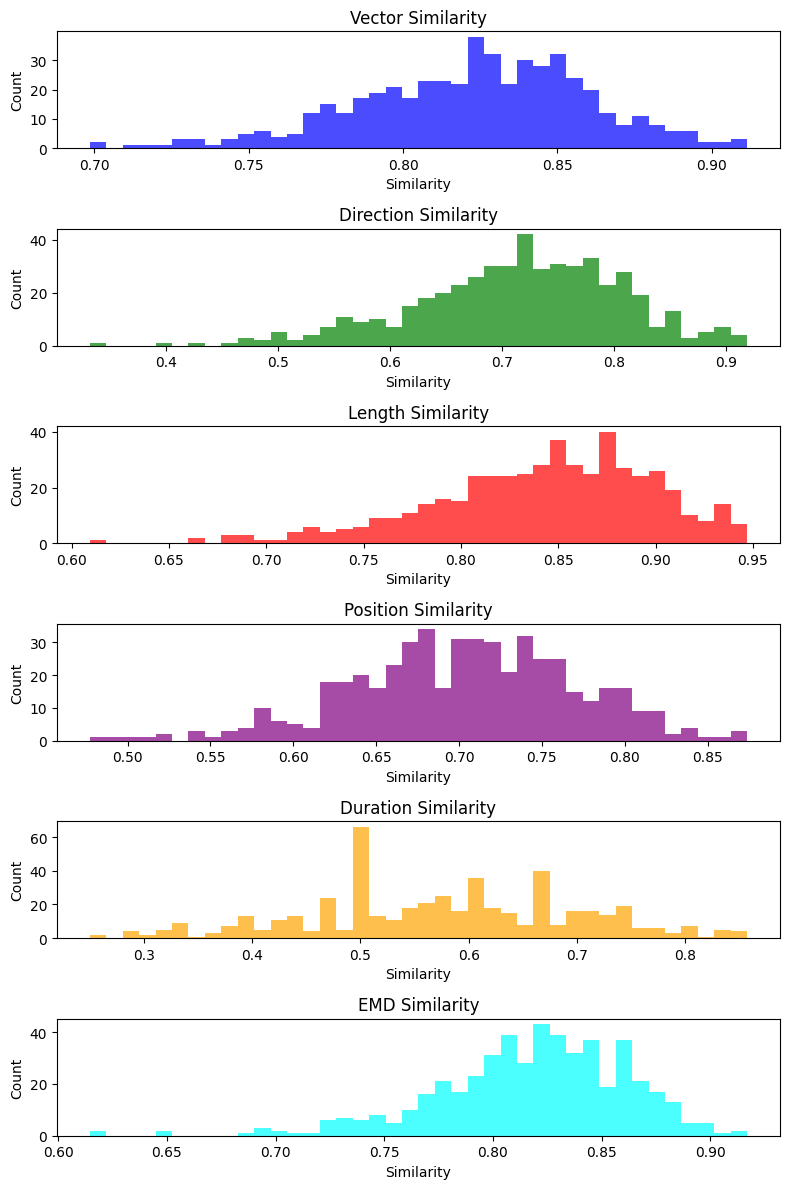

In [6]:
metrics = ["mm_vector", "mm_direction", "mm_length",
           "mm_position", "mm_duration", "mm_position_emd"]
labels = ["Vector", "Direction", "Length", "Position", "Duration", "EMD"]
colors = ["blue", "green", "red", "purple", "orange", "cyan"]

fig, axes = plt.subplots(6, 1, figsize=(8, 12))
for ax, m, lbl, c in zip(axes, metrics, labels, colors):
    ax.hist(ssdf[m].dropna(), bins=40, color=c, alpha=0.7)
    ax.set_xlabel("Similarity")
    ax.set_ylabel("Count")
    ax.set_title(f"{lbl} Similarity")
plt.tight_layout()
plt.show()

Each metric has a distinct baseline distribution. Direction similarity, for
instance, clusters near 0.5 for random pairs, while position similarity is
typically lower.

## How do transformations affect the metrics?

Understanding how each metric responds to spatial and temporal transformations
helps you choose the right one for your research question.

### Identity (perfect match)

In [7]:
rng = np.random.default_rng(7)
fg = fixation_group(
    rng.uniform(0, 500, 10), rng.uniform(0, 500, 10),
    np.round(rng.uniform(0, 10, 10)).astype(float) + 1,
    np.arange(1, 11, dtype=float),
)
print("Identity:")
multi_match(scanpath(fg), scanpath(fg), (500, 500))

Identity:


{'mm_vector': 1.0,
 'mm_direction': 1.0,
 'mm_length': 1.0,
 'mm_position': 1.0,
 'mm_duration': 1.0,
 'mm_position_emd': 1.0}

All metrics are 1.0 — a scanpath is perfectly similar to itself.

### Scaling

Scaling the coordinates by 0.5 preserves **direction** (relative
angles are unchanged) but reduces **position** (absolute locations differ):

In [8]:
fg_scaled = fg.copy()
fg_scaled["x"] = fg_scaled["x"] * 0.5
fg_scaled["y"] = fg_scaled["y"] * 0.5

print("Scaling (0.5x):")
multi_match(scanpath(fg), scanpath(fg_scaled), (500, 500))

Scaling (0.5x):


{'mm_vector': 0.9128833854076626,
 'mm_direction': 1.0,
 'mm_length': 0.8257667708153251,
 'mm_position': 0.6678642171257432,
 'mm_duration': 1.0,
 'mm_position_emd': 0.6595176258358477}

As expected, **direction** stays at 1.0, but **position** drops.

### Shuffling fixation order

Keeping the same fixation locations but scrambling their order preserves
**position** (and the EMD) while disrupting **direction**:

In [9]:
rng2 = np.random.default_rng(3)
fg_shuffled = fg.copy()
order = rng2.permutation(len(fg))
fg_shuffled["x"] = fg["x"].values[order]
fg_shuffled["y"] = fg["y"].values[order]
fg_shuffled["duration"] = fg["duration"].values[order]

print("Order-shuffled:")
multi_match(scanpath(fg), scanpath(fg_shuffled), (500, 500))

Order-shuffled:


{'mm_vector': 0.839991637411089,
 'mm_direction': 0.7616677039557632,
 'mm_length': 0.8660122859689672,
 'mm_position': 0.5950305699522862,
 'mm_duration': 0.5,
 'mm_position_emd': 0.9513767732507884}

The **position_emd** remains high (same spatial distribution), while
**direction** drops (the trajectory has changed).

## References

Dewhurst, R., Nyström, M., Jarodzka, H., Foulsham, T., Johansson, R., &
Holmqvist, K. (2012). It depends on how you look at it: Scanpath comparison in
multiple dimensions with MultiMatch, a vector-based approach. *Behavior
Research Methods*, 44, 1079–1100.